# Registration Pipeline Demo

Демонстрация многостадийного вписывания (coarse-to-fine) на синтетических данных:
- **IM1** — подвижное изображение (цветные кубы + гауссов шум)
- **IM2** — фиксированное изображение (IM1 деформировано известной трансформацией + шум)
- Запускаем `RegistrationPipeline` с разными оптимизаторами на каждой стадии
- Визуализируем через `Volume.visualize()`

In [1]:
# pip install -e ".[io]"  ← один раз в окружении
import os
from pathlib import Path
import torch
import matplotlib.pyplot as plt
from IPython.display import clear_output

from brain_morph.utils import Volume, MeshTransformer3D
from brain_morph.registration import (
    registration_cost,
    Stage, RegistrationPipeline, interpolate_grid,
    SAOptimizer, GradientOptimizer, HybridOptimizer,
)

# Project root — работает и из notebooks/, и из корня проекта
_cwd = Path(os.getcwd())
ROOT = str(_cwd.parent if _cwd.name == "notebooks" else _cwd)

print(f"torch {torch.__version__}  |  device: {'cuda' if torch.cuda.is_available() else 'cpu'}")
print(f"ROOT: {ROOT}")

torch 2.9.0  |  device: cpu
ROOT: /Users/air/Yandex.Disk.localized/IADoronin_from_Google/DL_engineer/brain morph


## 1. Синтетические изображения

In [2]:
def make_colored_volume(D=40, H=48, W=56, block=14, step=16, seed=0):
    """Цветные кубы, 3 канала. Форма (3, D, H, W)."""
    torch.manual_seed(seed)
    im = torch.zeros(3, D, H, W)
    for i in range(D // step):
        for j in range(H // step):
            for k in range(W // step):
                color = torch.rand(3).reshape(3, 1, 1, 1)
                im[:, i*step+1:i*step+1+block,
                      j*step+1:j*step+1+block,
                      k*step+1:k*step+1+block] = color
    return im  # (3, D, H, W)


D, H, W = 40, 48, 56
im0 = make_colored_volume(D, H, W)   # (3, D, H, W)

torch.manual_seed(11)
im1 = (im0 + torch.randn_like(im0) * 0.03).clamp(0, 1)  # (3, D, H, W)

grid_init_ref = torch.stack(
    torch.meshgrid(*[torch.linspace(-1, 1, s) for s in (4, 4, 4)], indexing="ij"),
    dim=-1,
)
torch.manual_seed(42)
grid_truth = grid_init_ref + torch.randn_like(grid_init_ref) * 0.20

t_ref = MeshTransformer3D(grid_init_ref, (D, H, W))
with torch.no_grad():
    im2_base = t_ref.transform(im0, grid_truth)  # (3, D, H, W)
torch.manual_seed(7)
im2 = (im2_base + torch.randn_like(im2_base) * 0.03).clamp(0, 1)

print(f"IM1 shape: {im1.shape},  IM2 shape: {im2.shape}")

IM1 shape: torch.Size([3, 40, 48, 56]),  IM2 shape: torch.Size([3, 40, 48, 56])


=== IM1 — подвижное (RGB, 3 канала) ===


/opt/anaconda3/envs/DL_CV_312/lib/python3.12/site-packages/torch/_tensor.py:1654: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/TensorShape.cpp:4419.)
  ret = func(*args, **kwargs)


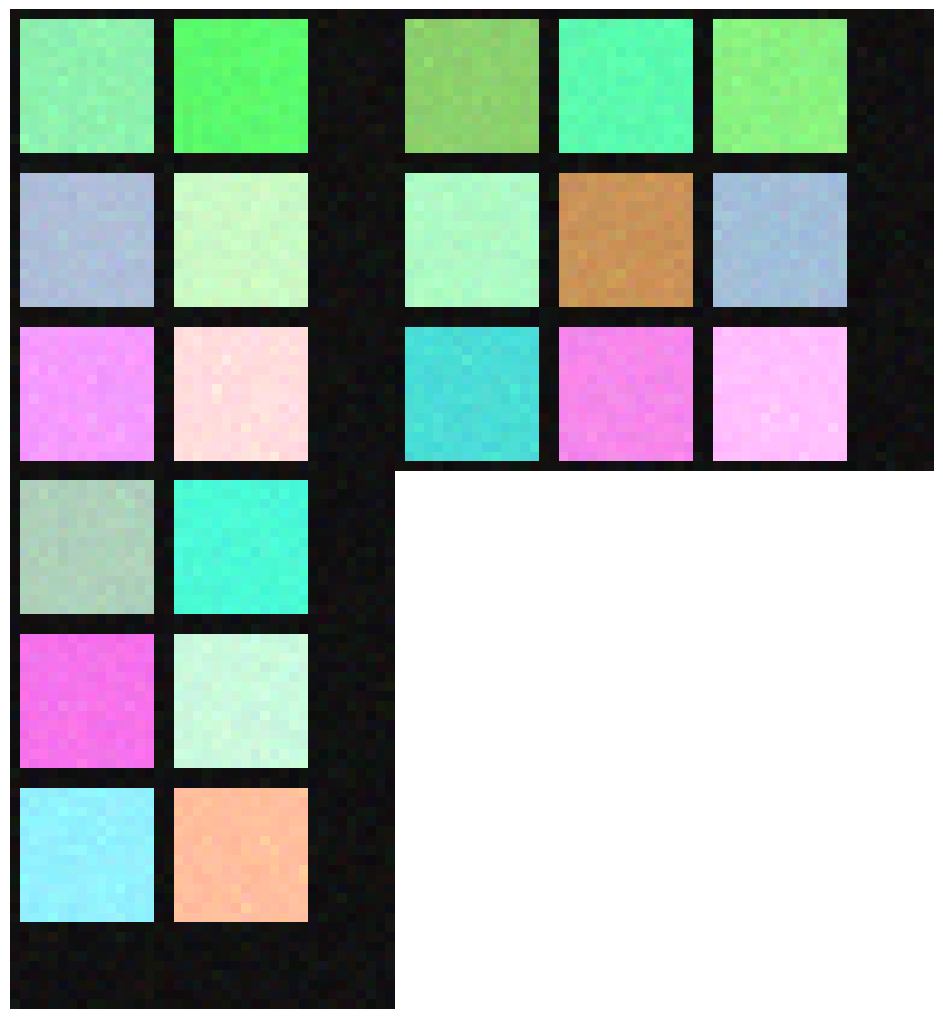

In [3]:
print("=== IM1 — подвижное (RGB, 3 канала) ===")
Volume(im1).visualize()

=== IM2 — фиксированное (деформировано, RGB) ===


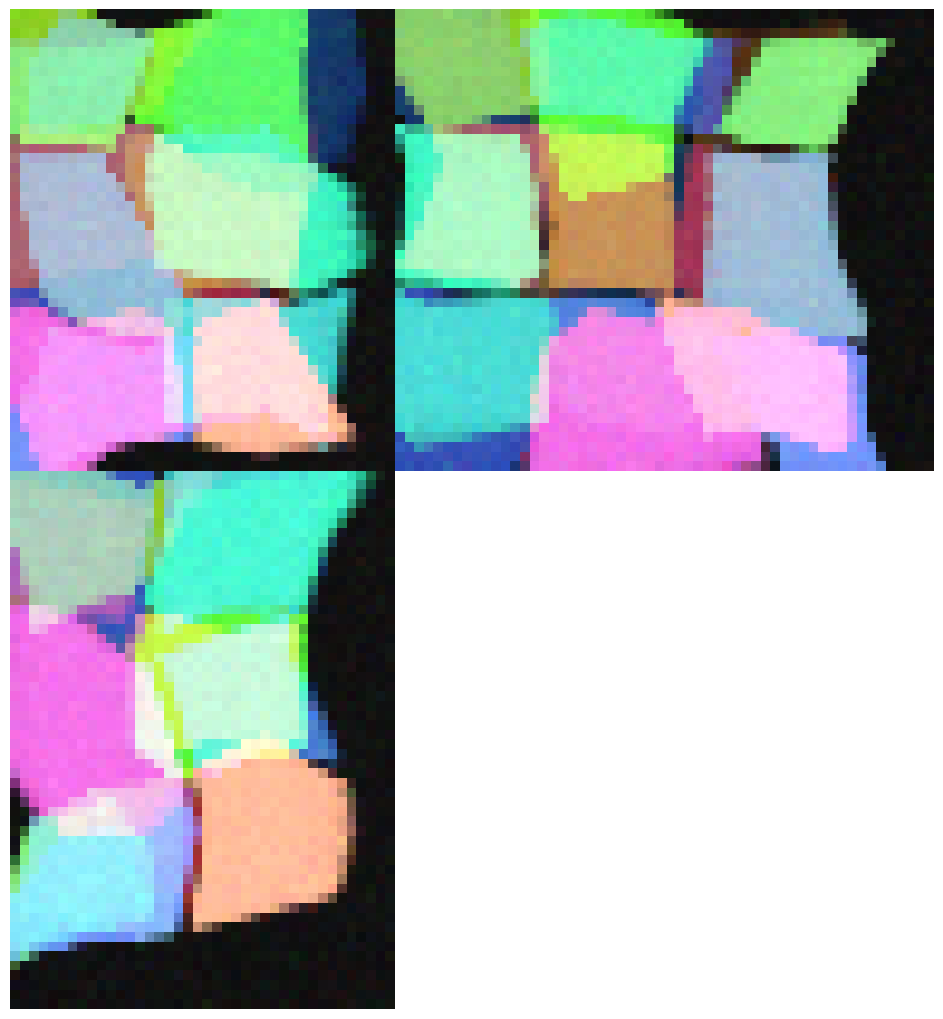

In [4]:
print("=== IM2 — фиксированное (деформировано, RGB) ===")
Volume(im2).visualize()

## 2. Сохранение и загрузка NIfTI

In [5]:
DATA_DIR = os.path.join(ROOT, "data", "synthetic")
os.makedirs(DATA_DIR, exist_ok=True)

path_im1 = os.path.join(DATA_DIR, "im1_moving.nii")
path_im2 = os.path.join(DATA_DIR, "im2_fixed.nii")

Volume(im1).save_nii(path_im1)   # (3, D, H, W) → NIfTI (D, H, W, 3)
Volume(im2).save_nii(path_im2)

print(f"Сохранено:\n  {path_im1}\n  {path_im2}")

Сохранено:
  /Users/air/Yandex.Disk.localized/IADoronin_from_Google/DL_engineer/brain morph/data/synthetic/im1_moving.nii
  /Users/air/Yandex.Disk.localized/IADoronin_from_Google/DL_engineer/brain morph/data/synthetic/im2_fixed.nii


Загружено: torch.Size([3, 40, 48, 56])  dtype=torch.float32
Max abs diff после round-trip: 0.00e+00
=== IM1 загруженное (фиксированное, RGB) ===


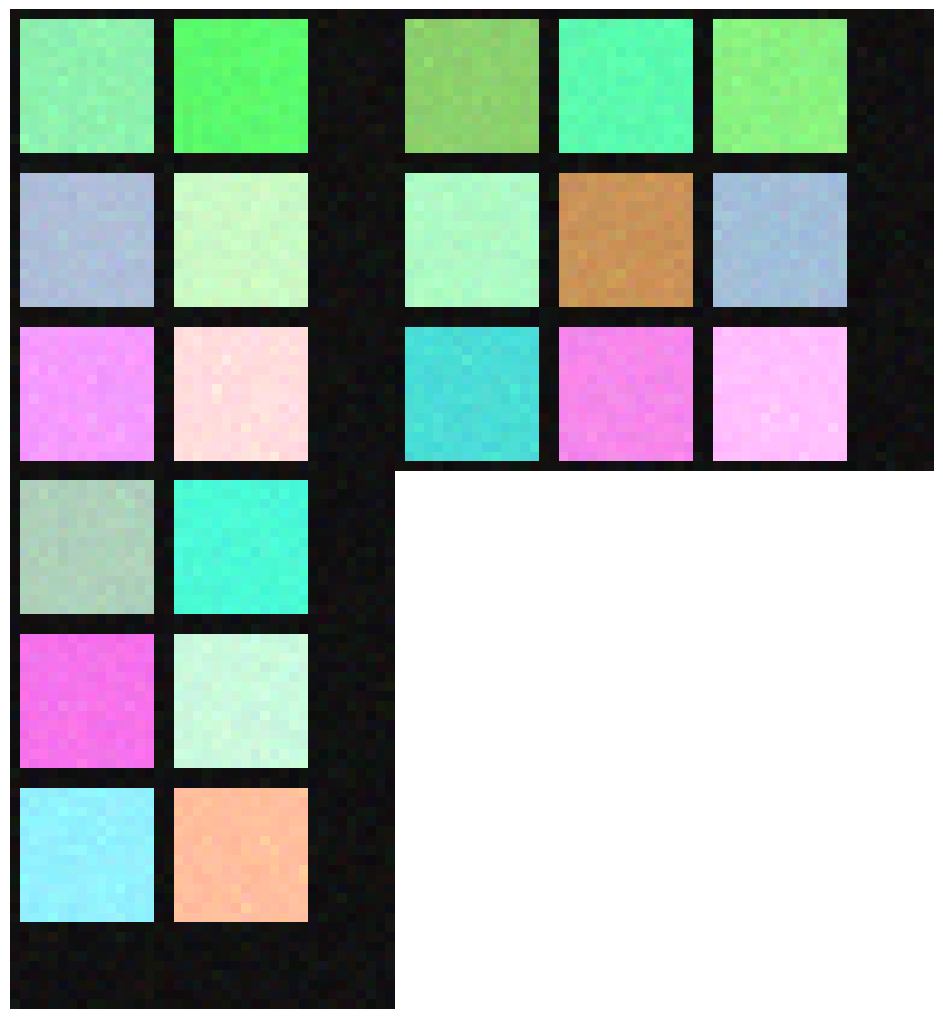

In [6]:
vol1_loaded = Volume.load_nii(path_im1)   # (3, D, H, W)
vol2_loaded = Volume.load_nii(path_im2)

im1_loaded = vol1_loaded   # (3, D, H, W)
im2_loaded = vol2_loaded

print(f"Загружено: {vol1_loaded.shape}  dtype={vol1_loaded.dtype}")
print(f"Max abs diff после round-trip: {(im1_loaded - im1).abs().max().item():.2e}")

# IM2 (деформированное) — подвижное; IM1 (оригинал) — фиксированное
im_moving = im2_loaded
im_fixed  = im1_loaded

# Веса каналов: первый канал важнее (аналог DAPI/GFP/RFP в конфокале)
w_channels = torch.tensor([0.5, 0.3, 0.2])

print("=== IM1 загруженное (фиксированное, RGB) ===")
vol1_loaded.visualize()

## 3. Baseline: identity transform

Correlation (identity): 0.5801
=== |IM_moving − IM_fixed| при identity (канал 0) ===


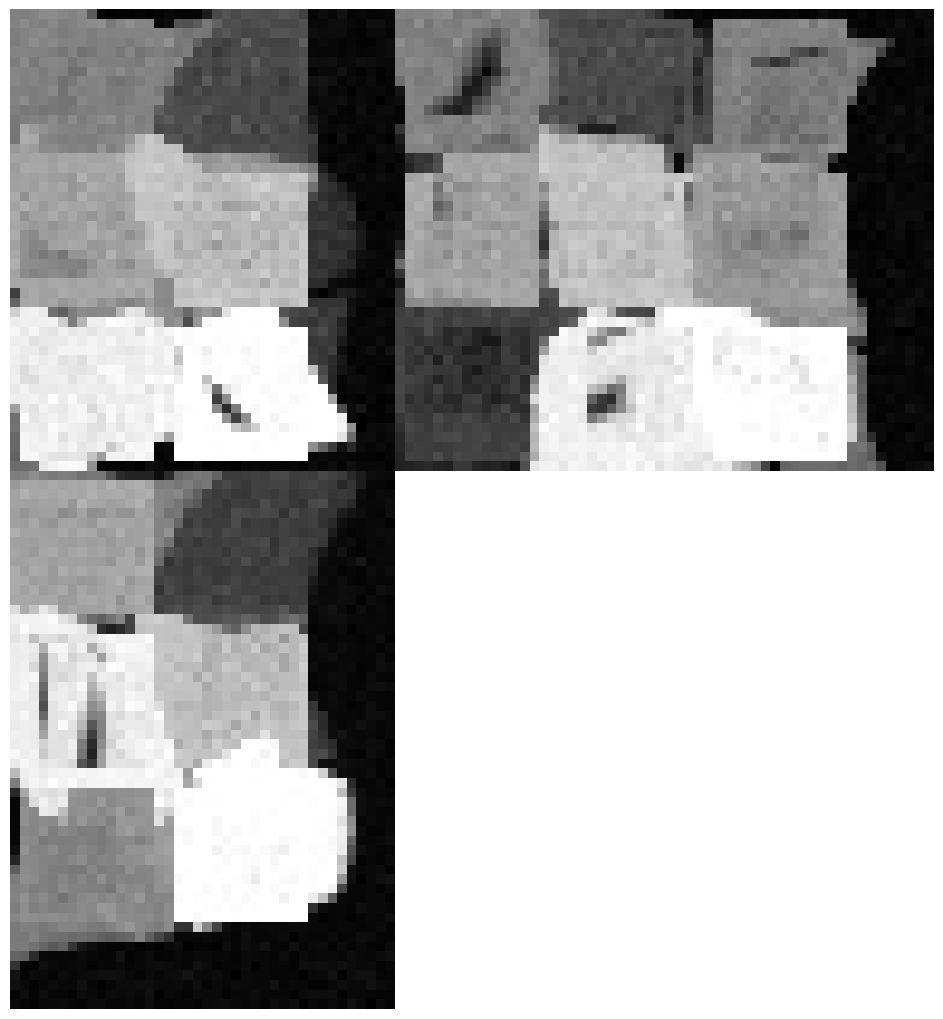

In [7]:
t_base = MeshTransformer3D(grid_init_ref, (D, H, W))
with torch.no_grad():
    warped_identity = t_base.transform(im_moving, grid_init_ref)  # (3, D, H, W)

cost_identity = registration_cost(
    im_moving, im_fixed, t_base, grid_init_ref, lam=0, channel_weights=w_channels
).item()
print(f"Correlation (identity): {cost_identity:.4f}")

diff_identity = (warped_identity - im_fixed).abs()  # (3, D, H, W)
print("=== |IM_moving − IM_fixed| при identity (канал 0) ===")
Volume(diff_identity).visualize(channel=0)

## 4. Настройка пайплайна

Callback вызывается каждые `callback_freq` шагов SA и обновляет ячейку вывода в реальном времени.

In [8]:
cost_log = []

def _live_cb(step, cost, warped):
    """Live update: max-projections (канал 0) + running cost curve."""
    cost_log.append((step, cost))
    clear_output(wait=True)
    print(f"step {step:5d}  |  cost = {cost:.5f}  |  warped: {tuple(warped.shape)}")

    # Upsample to full spatial resolution if downsampled
    if tuple(warped.shape[-3:]) != (D, H, W):
        w4 = warped.unsqueeze(0).float()          # (1, C, d, h, w)
        warped_disp = torch.nn.functional.interpolate(
            w4, size=(D, H, W), mode="trilinear", align_corners=False,
        ).squeeze(0)                               # (C, D, H, W)
    else:
        warped_disp = warped

    # Use channel 0 for per-projection display
    ch = warped_disp[0] if warped_disp.dim() == 4 else warped_disp
    fx = im_fixed[0]   if im_fixed.dim()   == 4 else im_fixed
    diff = (ch - fx).abs()

    fig, axes = plt.subplots(2, 3, figsize=(10, 5))
    projs_w = [ch.amax(0),   ch.amax(1),   ch.amax(2)]
    projs_d = [diff.amax(0), diff.amax(1), diff.amax(2)]
    for col, (pw, pd, title) in enumerate(zip(projs_w, projs_d, ["ax D", "ax H", "ax W"])):
        axes[0, col].imshow(pw.cpu(), cmap="gray", vmin=0, vmax=1)
        axes[0, col].set_title(f"warped ch0 ({title})")
        axes[0, col].axis("off")
        axes[1, col].imshow(pd.cpu(), cmap="hot", vmin=0, vmax=0.5)
        axes[1, col].set_title(f"|diff| ch0 ({title})")
        axes[1, col].axis("off")
    plt.tight_layout()
    plt.show()

    if len(cost_log) > 1:
        steps_, costs_ = zip(*cost_log)
        fig2, ax2 = plt.subplots(figsize=(9, 2))
        ax2.plot(steps_, costs_, color="tab:blue", lw=1)
        ax2.set_xlabel("global step"); ax2.set_ylabel("cost")
        ax2.set_title("cost по ходу оптимизации")
        plt.tight_layout()
        plt.show()


_sa_kw = dict(coeff_start=0.10, coeff_drop=0.9966, attention_freq=50,
              callback=_live_cb, callback_freq=200)

sa_1 = SAOptimizer(temp_start=1e-3, temp_end=1e-5, **_sa_kw)
sa_2 = SAOptimizer(temp_start=1e-3, temp_end=1e-5, **_sa_kw)
sa_3 = SAOptimizer(temp_start=1e-4, temp_end=1e-6, **_sa_kw)
gd_refine = GradientOptimizer(optimizer_cls=torch.optim.Adam, lr=5e-4, tension_mode="squared")

pipeline = RegistrationPipeline([
    Stage(grid_shape=(2, 2, 2), optimizer=sa_1,      n_steps=2000, lam=5e-2, image_scale=8),
    Stage(grid_shape=(5, 3, 2), optimizer=sa_2,      n_steps=2000, lam=2e-2, image_scale=8),
    Stage(grid_shape=(5, 5, 4), optimizer=sa_3,      n_steps=2000, lam=1e-2, image_scale=4),
    Stage(grid_shape=(5, 5, 4), optimizer=gd_refine, n_steps=300,  lam=2e-3, image_scale=1),
])

print("Пайплайн: SA(2³,2k,×8) → SA(5×3×2,2k,×8) → SA(5³,2k,×4) → GD(5³,300,×1)")
print(f"Веса каналов: {w_channels.tolist()}")

Пайплайн: SA(2³,2k,×8) → SA(5×3×2,2k,×8) → SA(5³,2k,×4) → GD(5³,300,×1)
Веса каналов: [0.5, 0.30000001192092896, 0.20000000298023224]


## 5. Запуск

Во время SA ячейка ниже обновляется в реальном времени каждые 50 шагов.

In [9]:
torch.manual_seed(99)
cost_log.clear()

grid_result = pipeline.run(im_moving, im_fixed, channel_weights=w_channels)

clear_output(wait=True)
print(f"Готово. Итоговая форма сетки: {grid_result.shape}")

Готово. Итоговая форма сетки: torch.Size([5, 5, 4, 3])


## 6. Результат

Correlation identity: 0.5801
Correlation result:   0.8956  (Δ = +0.3155)

=== Warped IM_moving (после регистрации, RGB) ===


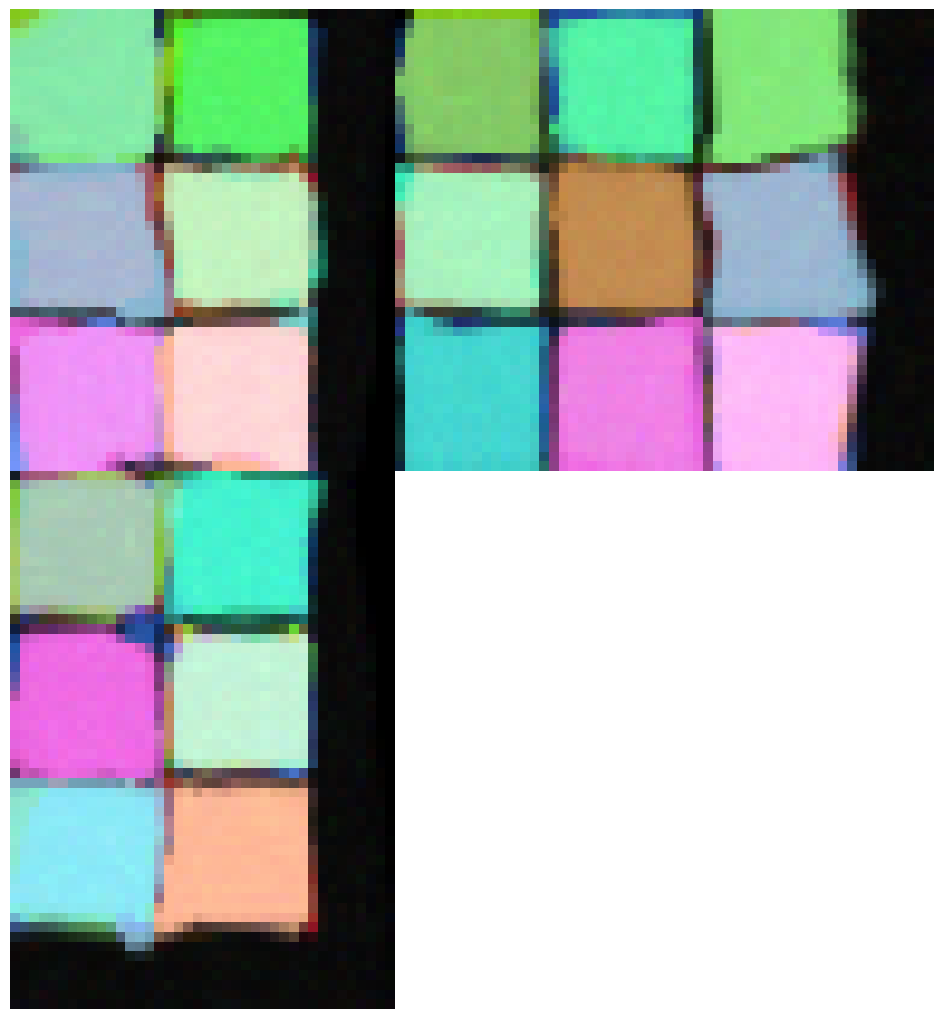

In [10]:
grid_init_final = torch.stack(
    torch.meshgrid(*[torch.linspace(-1, 1, s) for s in grid_result.shape[:3]], indexing="ij"),
    dim=-1,
)
t_final = MeshTransformer3D(grid_init_final, (D, H, W))

with torch.no_grad():
    warped_result = t_final.transform(im_moving, grid_result)  # (3, D, H, W)

cost_result = registration_cost(
    im_moving, im_fixed, t_final, grid_result, lam=0, channel_weights=w_channels
).item()
print(f"Correlation identity: {cost_identity:.4f}")
print(f"Correlation result:   {cost_result:.4f}  (Δ = {cost_result - cost_identity:+.4f})")

diff_result = (warped_result - im_fixed).abs()  # (3, D, H, W)
print("\n=== Warped IM_moving (после регистрации, RGB) ===")
Volume(warped_result).visualize()

=== |Warped − IM_fixed| (остаточная разность, канал 0) ===


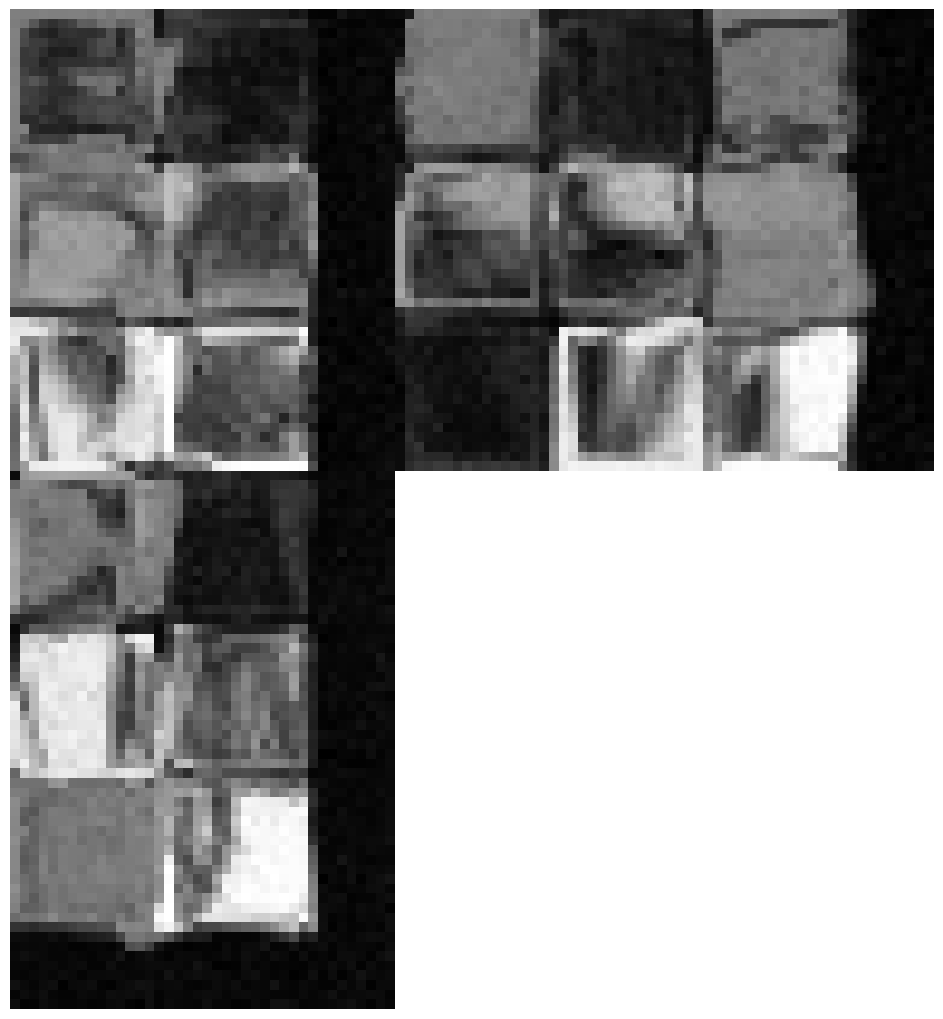

In [11]:
print("=== |Warped − IM_fixed| (остаточная разность, канал 0) ===")
Volume(diff_result).visualize(channel=0)

## 7. График метрики за всё время

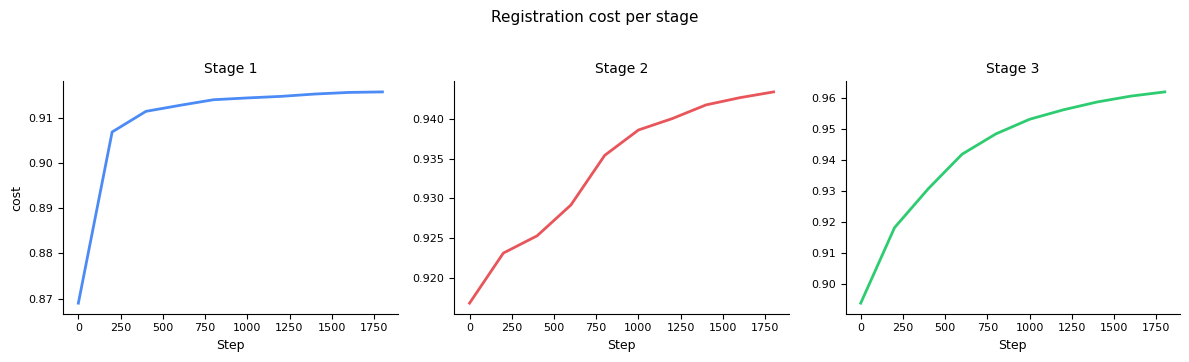

In [12]:
if cost_log:
    # Разбиваем по стадиям (счётчик шагов сбрасывается при смене стадии)
    stages_data = []
    current = []
    for i, (s, c) in enumerate(cost_log):
        if i > 0 and s < cost_log[i-1][0]:
            stages_data.append(current)
            current = []
        current.append((s, c))
    stages_data.append(current)

    COLORS = ["#4C8BF5", "#E8555A", "#2ECC71", "#F5A623"]
    n = len(stages_data)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 3.5))
    if n == 1:
        axes = [axes]

    for i, (stage_data, ax) in enumerate(zip(stages_data, axes)):
        steps_, costs_ = zip(*stage_data)
        color = COLORS[i % len(COLORS)]
        ax.plot(steps_, costs_, color=color, alpha=0.3, linewidth=0.7)
        # Скользящее среднее
        w = max(1, len(costs_) // 20)
        import numpy as np
        sm = np.convolve(costs_, np.ones(w)/w, mode="same")
        ax.plot(steps_, sm, color=color, linewidth=2)
        ax.set_title(f"Stage {i+1}", fontsize=10)
        ax.set_xlabel("Step", fontsize=9)
        if i == 0:
            ax.set_ylabel("cost", fontsize=9)
        ax.spines[["top", "right"]].set_visible(False)
        ax.tick_params(labelsize=8)

    plt.suptitle("Registration cost per stage", fontsize=11, y=1.02)
    plt.tight_layout()
    plt.show()

## 8. Сравнение до/после (max-проекция)

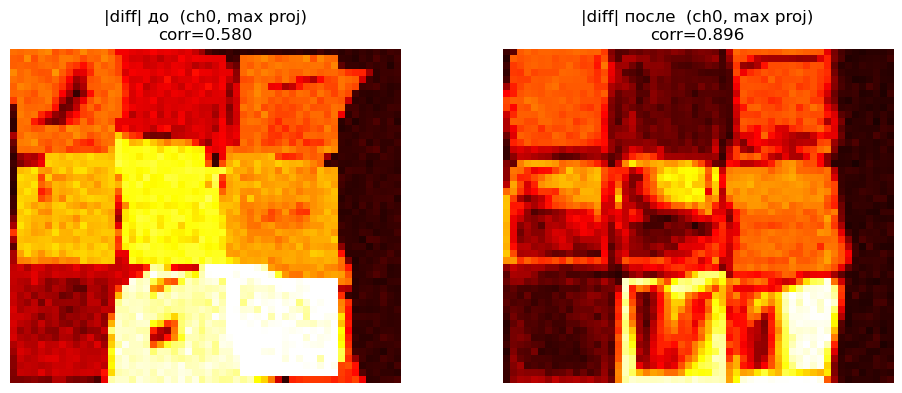

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Канал 0 для сравнения до/после
proj_before = diff_identity[0].amax(dim=0).cpu().numpy()
proj_after  = diff_result[0].amax(dim=0).cpu().numpy()
vmax = max(proj_before.max(), proj_after.max())

axes[0].imshow(proj_before, cmap="hot", vmin=0, vmax=vmax)
axes[0].set_title(f"|diff| до  (ch0, max proj)\ncorr={cost_identity:.3f}")
axes[0].axis("off")

axes[1].imshow(proj_after, cmap="hot", vmin=0, vmax=vmax)
axes[1].set_title(f"|diff| после  (ch0, max proj)\ncorr={cost_result:.3f}")
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 9. Сохранение результата

In [14]:
path_warped = os.path.join(DATA_DIR, "im1_warped.nii")
Volume(warped_result).save_nii(path_warped)
print(f"Результат сохранён: {path_warped}")

Результат сохранён: /Users/air/Yandex.Disk.localized/IADoronin_from_Google/DL_engineer/brain morph/data/synthetic/im1_warped.nii
